# 🏗️ Transformer Architecture

This notebook explains the core architecture that powers modern large language models like GPT, BERT, and T5 — the **Transformer**.


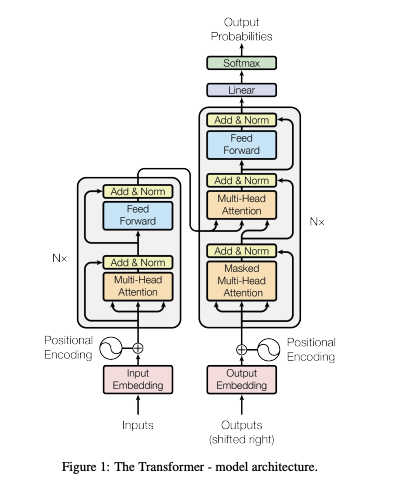

---


## 🧱 High-Level Structure

The original Transformer, introduced in the paper ["Attention is All You Need"](https://arxiv.org/abs/1706.03762), has two main parts:
- **Encoder**: Converts input text into a contextual representation
- **Decoder**: Converts representation into output text

### But in practice:
- BERT uses only **Encoder blocks** (good for understanding tasks)
- GPT uses only **Decoder blocks** (good for generation tasks)
- T5 and BART use **Encoder-Decoder blocks**

---

### 🔁 Transformer Block (One Layer)

Each block has:
1. **Multi-head Self-Attention**
2. **Feedforward Neural Network**
3. **LayerNorm + Residual Connections**


> ℹ️ Imagine this flow:
>
> 🧠 Input → [LayerNorm → Attention → Add & Norm → FFN → Add & Norm] → Output
>
> 🔁 Stack N such blocks for deep models (e.g., 12 layers in BERT-base)

---


## 🔍 Components in Detail

### 1. Multi-head Self-Attention
- Attention is computed multiple times in parallel
- Each "head" learns a different relationship
- Outputs are concatenated and linearly projected

### 2. Feedforward Neural Network (FFN)
Each token is passed through the same FFN:
$$\text{FFN}(x) = \text{ReLU}(xW_1 + b_1)W_2 + b_2$$

### 3. Residual Connections + LayerNorm
Stabilizes training and helps gradients flow.

---


## ⌛ Positional Encoding

Since transformers don't have recurrence, we inject positional information:
$$
PE(pos, i) = \begin{cases}
\sin(pos / 10000^{i/d}) & \text{if } i \text{ is even} \\
\cos(pos / 10000^{i/d}) & \text{if } i \text{ is odd}
\end{cases}
$$

This is added to input embeddings to help the model understand order.

---


In [1]:
import torch
from torch import nn

class SimpleTransformerBlock(nn.Module):
    def __init__(self, embed_dim, heads):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim, heads, batch_first=True)
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 4),
            nn.ReLU(),
            nn.Linear(embed_dim * 4, embed_dim)
        )
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)

    def forward(self, x):
        attn_output, _ = self.attn(x, x, x)
        x = self.norm1(x + attn_output)
        ffn_output = self.ffn(x)
        return self.norm2(x + ffn_output)

# Sample input: 5 tokens, embedding size 64
x = torch.rand(1, 5, 64)
model = SimpleTransformerBlock(embed_dim=64, heads=4)
output = model(x)
print(output.shape)


torch.Size([1, 5, 64])


## ✅ Summary

- Transformers use attention to process all words in parallel.
- Each layer refines token representations with attention and feedforward logic.
- Positional encoding gives the model sequence understanding.
- Most modern LLMs are built by stacking these blocks.

---